# 01 - HC3 exploratory data analysis

HC3 (Guo et al., 2023)

1. Load
2. Remove collection errors and duplicates
3. Class and domain balance
4. Formatting artefacts
5. Normalisation
6. Effect of normalisation on length
7. Length distribution
8. Length control
9. Preprocessed corpus and split

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

LABELS = {0: "human", 1: "chatgpt"}

## 1. Loading
All five domains are loaded together, so domain can be used as a source of shift.

In [2]:
from logos.project_data.hc3 import load_hc3

hc3 = load_hc3()
print(hc3.shape)
print(hc3.nunique())
print("duplicate texts:", hc3["text"].duplicated().sum())

(85431, 6)
text           79331
label              2
generator          2
family             2
domain             5
question_id    24322
dtype: int64
duplicate texts: 6100


## 2. Collection errors and duplicates
6,100 rows repeat an earlier text. Looking at the most repeated texts:

In [3]:
hc3["text"].value_counts().head(10)

text
!\nToo many requests in 1 hour. Try again later.\n\n\n\nThere was an error generating a response                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            27
!Your authentication token has expired. Please try s

The most repeated texts are ChatGPT UI messages ("Too many requests in 1 hour", "Your authentication token has expired") that were recorded instead of answers. `clean_hc3` removes these by pattern, then drops exact duplicates. Where the removed rows came from:

In [4]:
from logos.project_data.hc3 import clean_hc3

cleaned = clean_hc3(hc3)

errors = hc3[~hc3["text"].isin(cleaned["text"])]
print("error rows removed by clean_hc3:", len(errors), errors["label"].map(LABELS).value_counts().to_dict())

non_error = hc3[hc3["text"].isin(cleaned["text"])]
duplicates = non_error[non_error["text"].duplicated()]

print("duplicate rows removed:", len(duplicates), duplicates["label"].map(LABELS).value_counts().to_dict())
print("cleaned:", cleaned.shape)

error rows removed by clean_hc3: 171 {'chatgpt': 171}
duplicate rows removed: 5990 {'human': 5460, 'chatgpt': 530}
cleaned: (79270, 6)


All 171 error rows are ChatGPT, while most duplicates are human. The pattern matches full error phrases: shorter fragments such as "Too many requests" and "There was an error" also matched three genuine answers:

In [5]:
loose = r"Too many requests|authentication token|network error|There was an error|ChatGPT Dec \d+ Version|Clear conversations"
tight = r"Too many requests in 1 hour|authentication token has expired|network error|There was an error generating a response|ChatGPT Dec \d+ Version|Clear conversations"

only_loose = hc3["text"].str.contains(loose, case=False) & ~hc3["text"].str.contains(tight, case=False)
hc3.loc[only_loose, ["label", "text"]]

,label,text
4414,0,"The French has Le , La , and Les . The Spanish..."
24286,0,""" Stack overflow "" is a programming term relat..."
75825,1,To fetch technical indicators from Yahoo's API...


## 3. Class and domain balance

In [6]:
cleaned["label"].map(LABELS).value_counts()

label
human      53086
chatgpt    26184
Name: count, dtype: int64

In [7]:
cleaned.groupby(["domain", cleaned["label"].map(LABELS)]).size().unstack(fill_value=0)

label,chatgpt,human
domain,,
finance,4457,3933
medicine,1299,1246
open_qa,3516,1171
reddit_eli5,16071,45965
wiki_csai,841,771


Human answers outnumber ChatGPT about 2:1, and reddit_eli5 is about 78% of the corpus. Neither is rebalanced: TPR@1%FPR is unaffected by class prevalence, and training uses `class_weight="balanced"`. Results are broken down by domain.

## 4. Formatting artefacts
HC3's human answers come from older datasets, many of which were distributed pre-tokenised ("don't" -> "do n't", spaces around punctuation, links replaced with `URL_n`). The ChatGPT answers were collected unedited. If the two sides differ in formatting, a detector can separate them by formatting rather than by authorship. Checking for signs of tokenisation, by class and domain:

In [8]:
signals = {
    "split n't": r" n't\b",
    "split 's / 're / 've / 'll / 'd": r" '(?:s|re|ve|ll|d)\b",
    "space before comma": r" ,",
    "spaced dollar": r"\$ \d",
    "spaced percent": r"\d %",
    "URL placeholder": r"URL_\d+",
    "spaced quotes": r'\s"\s',
    "spaced hyphen": r"\w - \w",
    "spaced asterisks": r"\s\*\s",
}

def signal_rates(df):
    hits = pd.DataFrame({name: df["text"].str.contains(p) for name, p in signals.items()})
    return hits.groupby([df["label"].map(LABELS), df["domain"]]).mean()

signal_rates(cleaned)

split n't  split 's / 're / 've / 'll / 'd  \
label   domain                                                    
chatgpt finance       0.000000                         0.000000   
        medicine      0.000000                         0.000000   
        open_qa       0.000000                         0.000000   
        reddit_eli5   0.000124                         0.000124   
        wiki_csai     0.000000                         0.000000   
human   finance       0.000000                         0.000254   
        medicine      0.000000                         0.001605   
        open_qa       0.000000                         0.013664   
        reddit_eli5   0.389992                         0.521854   
        wiki_csai     0.000000                         0.000000   

                     space before comma  spaced dollar  spaced percent  \
label   domain                                                           
chatgpt finance                0.000449       0.000000        0.000000   
        medicine               0.000000       0.000000        0.000000   
        open_qa                0.000000       0.000000        0.000000   
        reddit_eli5            0.000373       0.000000        0.000062   
        wiki_csai              0.000000       0.000000        0.000000   
human   finance                0.007882       0.001780        0.002288   
        medicine               0.104334       0.000000        0.003210   
        open_qa                0.390265       0.000000        0.000000   
        reddit_eli5            0.816752       0.024475        0.035309   
        wiki_csai              0.002594       0.000000        0.000000   

                     URL placeholder  spaced quotes  spaced hyphen  \
label   domain                                                       
chatgpt finance             0.000000       0.000000       0.008302   
        medicine            0.000000       0.000000       0.001540   
        open_qa             0.000000       0.000000       0.003413   
        reddit_eli5         0.001369       0.000373       0.013254   
        wiki_csai           0.000000       0.000000       0.007134   
human   finance             0.000000       0.001017       0.139588   
        medicine            0.000000       0.001605       0.040931   
        open_qa             0.000000       0.011956       0.005124   
        reddit_eli5         0.132710       0.237224       0.268313   
        wiki_csai           0.000000       0.001297       0.009079   

                     spaced asterisks  
label   domain                         
chatgpt finance              0.007404  
        medicine             0.000000  
        open_qa              0.001991  
        reddit_eli5          0.001556  
        wiki_csai            0.003567  
human   finance              0.009916  
        medicine             0.005618  
        open_qa              0.000000  
        reddit_eli5          0.128794  
        wiki_csai            0.000000

The artefacts are almost entirely on the human side: concentrated in reddit_eli5, with spaced commas also common in open_qa and medicine, and near zero for ChatGPT in every domain. Not everything one-sided is an artefact, though. Emoticons are also almost exclusively human:

In [9]:
emoticon = cleaned["text"].str.contains(r" [:;]-?[)(DP]")
emoticon.groupby([cleaned["domain"], cleaned["label"].map(LABELS)]).sum().unstack(fill_value=0)

label,chatgpt,human
domain,,
finance,0,53
medicine,0,0
open_qa,0,0
reddit_eli5,1,452
wiki_csai,0,0


The test for removal is whether a feature was introduced by the writer or by the dataset's processing. Nobody types `$ 4` or `do n't`; those spaces come from a tokeniser. People do type `:)`, and ChatGPT doesn't, so emoticons are a genuine stylistic difference and are kept.

## 5. Normalisation
Following common practice [21], [33], every text, whichever class, domain or corpus it comes from, goes through the same `normalise_text`:
- Links and `URL_n` placeholders are removed, keeping the link text of markdown links.
- NLTK's Treebank detokeniser reverses the tokenisation.

URL removal runs first, because deleting a placeholder leaves a space that the detokeniser then tidies. Re-checking the signals:

In [10]:
from logos.project_data.preprocess import normalise_text

normalised = cleaned.assign(text=cleaned["text"].apply(normalise_text))
signal_rates(normalised)

split n't  split 's / 're / 've / 'll / 'd  \
label   domain                                                    
chatgpt finance            0.0                         0.000000   
        medicine           0.0                         0.000000   
        open_qa            0.0                         0.000000   
        reddit_eli5        0.0                         0.000000   
        wiki_csai          0.0                         0.000000   
human   finance            0.0                         0.000254   
        medicine           0.0                         0.000000   
        open_qa            0.0                         0.000000   
        reddit_eli5        0.0                         0.000065   
        wiki_csai          0.0                         0.000000   

                     space before comma  spaced dollar  spaced percent  \
label   domain                                                           
chatgpt finance                     0.0            0.0             0.0   
        medicine                    0.0            0.0             0.0   
        open_qa                     0.0            0.0             0.0   
        reddit_eli5                 0.0            0.0             0.0   
        wiki_csai                   0.0            0.0             0.0   
human   finance                     0.0            0.0             0.0   
        medicine                    0.0            0.0             0.0   
        open_qa                     0.0            0.0             0.0   
        reddit_eli5                 0.0            0.0             0.0   
        wiki_csai                   0.0            0.0             0.0   

                     URL placeholder  spaced quotes  spaced hyphen  \
label   domain                                                       
chatgpt finance                  0.0       0.000000       0.008302   
        medicine                 0.0       0.000000       0.001540   
        open_qa                  0.0       0.000000       0.003413   
        reddit_eli5              0.0       0.000000       0.013254   
        wiki_csai                0.0       0.000000       0.007134   
human   finance                  0.0       0.000000       0.142131   
        medicine                 0.0       0.000000       0.044944   
        open_qa                  0.0       0.000000       0.005124   
        reddit_eli5              0.0       0.003437       0.268139   
        wiki_csai                0.0       0.000000       0.009079   

                     spaced asterisks  
label   domain                         
chatgpt finance                   0.0  
        medicine                  0.0  
        open_qa                   0.0  
        reddit_eli5               0.0  
        wiki_csai                 0.0  
human   finance                   0.0  
        medicine                  0.0  
        open_qa                   0.0  
        reddit_eli5               0.0  
        wiki_csai                 0.0

Spaced hyphens remain (27% of reddit_eli5 and 14% of finance human answers). They are left in place: finance shows no other sign of tokenisation, so there they are how writers type a dash, and no rule can separate a tokenised compound ("year - old") from a typed dash ("this - that").

Every signal is now at or near zero. Any remaining hit is worth reading before it's trusted:

In [11]:
checked = [p for name, p in signals.items() if name != "spaced hyphen"]
remaining = normalised["text"].str.contains("|".join(checked))
normalised.loc[remaining, ["label", "domain", "text"]]

,label,domain,text
413,0,reddit_eli5,conductive fields decrease by the square of th...
2314,0,reddit_eli5,"It's actually 1 1/2 "" x 3 1/2 "". The explanati..."
2478,0,reddit_eli5,French here. I thought I might give some insig...
2526,0,reddit_eli5,Basically it finds repeating patterns and save...
3837,0,reddit_eli5,It depends what you mean when you are talking ...
...,...,...,...
59770,0,reddit_eli5,Hmm well growing up both in the USA and in Eur...
59932,0,reddit_eli5,Let's take the fictional address /usa / maine ...
60668,0,reddit_eli5,Silliness. Where I live: Switchblades illegal ...
61868,0,reddit_eli5,Music is based on ratios. The perceived pitch ...


> "On what basis did you do your initial allocation of funds to each stock? If you are 're-balancing' that implies returning things to their initial allocation. You can do this without any research or recommendations. If you started out with say 10 stocks and 10% of the funds allocated to each stock, then re-balancing would simply be either buying/selling to return to that initial allocation. If you are contributing to the portfolio you could adjust where the new money goes to re-balance without selling. Or if you are drawing money from the portfolio, then you could adjust what you are selling. If on the other hand you are trying to decide if you want to alter the stocks the portfolio is HOLDING, then you have an entirely different question from 're-balancing'"

The finance row seen here uses `'re-balancing'`, a word in quotation marks, so it's a false positive of the check rather than an artefact. The detokeniser correctly leaves it alone.

## 6. Effect of normalisation on length
Splitting on whitespace counted every spaced-out comma, full stop and `n't` as a separate token, so tokenised text looked longer than it was. How much did normalisation change the counts?

In [12]:
before = cleaned["text"].str.split().map(len)
after = normalised["text"].str.split().map(len)

print("new duplicates created by normalisation:", normalised["text"].duplicated().sum())
(before - after).groupby(cleaned["label"].map(LABELS)).describe()

new duplicates created by normalisation: 2


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
chatgpt,26184.0,0.045333,0.410457,0.0,0.0,0.0,0.0,15.0
human,53086.0,16.514222,26.057977,0.0,4.0,9.0,20.0,1954.0


In [13]:
human = cleaned["label"] == 0
((before - after) / before)[human].groupby(cleaned.loc[human, "domain"]).describe()

,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
finance,3933.0,0.003536,0.012374,0.0,0.000000,0.000000,0.000000,0.272727
medicine,1246.0,0.007536,0.018665,0.0,0.000000,0.000000,0.006163,0.162162
open_qa,1171.0,0.046246,0.052627,0.0,0.000000,0.035714,0.068071,0.368421
reddit_eli5,45965.0,0.142575,0.059787,0.0,0.106061,0.134146,0.166667,1.000000
wiki_csai,771.0,0.001348,0.006744,0.0,0.000000,0.000000,0.000000,0.095238


In [14]:
i = (before - after).idxmax()
print(before[i], "->", after[i], "|", cleaned.loc[i, "domain"])
print(cleaned.loc[i, "text"][:800])
print("---")
print(normalised.loc[i, "text"][:800])

7904 -> 5950 | reddit_eli5
Okay , explained like you 're a five year - old ( well , okay , maybe a bit older ) , without too much oversimplification , and ( hopefully ) without sounding too biased : What people call " Obamacare " is actually the Patient Protection and Affordable Care Act ( abbreviated to PPACA or ACA ) . However , people were calling it " Obamacare " before everyone even hammered out what it would * be * . It 's a term that was , at first , mostly used by people who did n't like the PPACA , and it 's become popularized in part because PPACA is a really long and awkward name , even when you turn it into an acronym like that . Barack Obama has since said that he actually * likes * the term " Obamacare " because , he says , " I do care " . Anyway , the PPACA made a bunch of new rules regarding health c
---
Okay, explained like you're a five year - old (well, okay, maybe a bit older), without too much oversimplification, and (hopefully) without sounding too biased: What pe

The raw token counts overestimate human length, so lengths are measured on normalised text.

## 7. Length distribution

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
chatgpt,26184.0,173.854377,60.654677,1.0,132.0,174.0,212.0,639.0
human,53084.0,118.369113,142.809891,0.0,37.0,74.0,144.0,5950.0


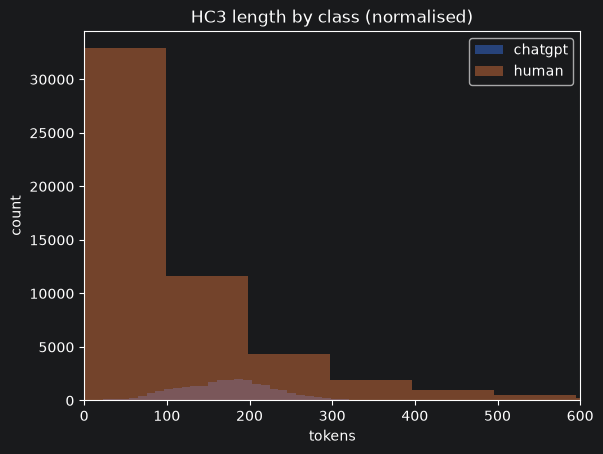

In [15]:
corpus = (normalised.drop_duplicates(subset="text")
                .assign(n_tokens=lambda d: d["text"].str.split().map(len)))

display(corpus.groupby(corpus["label"].map(LABELS))["n_tokens"].describe())

for name, group in corpus.groupby(corpus["label"].map(LABELS)):
    plt.hist(group["n_tokens"], bins=60, alpha=.5, label=name)

plt.xlim(0, 600)
plt.xlabel("tokens")
plt.ylabel("count")
plt.legend()
plt.title("HC3 length by class (normalised)")
plt.show()

ChatGPT answers are tightly distributed (median 174 tokens, IQR 132–212); human answers are shorter and heavy-tailed (median 74, IQR 37–146, max 6,345). Some human answers are empty after normalisation (min 0): answers that were only a link. The length filter removes them.

## 8. Length control

Following [19] and [33], answers shorter than 10 words are removed as too short to score meaningfully. How many that removes, and how many only fall below 10 because normalisation removed their padding:

In [16]:
short = corpus["n_tokens"] < 10
print("removed:", short.sum(), corpus.loc[short, "label"].map(LABELS).value_counts().to_dict())

pushed_under = (before >= 10) & (after < 10)
print("below 10 only after normalisation:", pushed_under.sum(),
      cleaned.loc[pushed_under, "label"].map(LABELS).value_counts().to_dict())

removed: 1219 {'human': 1188, 'chatgpt': 31}
below 10 only after normalisation: 687 {'human': 687}


A minimum length does not stop length separating the classes: ChatGPT answers cluster tightly while human answers are shorter and heavy-tailed, so a detector can learn length as a shortcut [24]. Following [24], each ChatGPT answer is paired with a human answer to the same question whose length is within ±20%, and unmatched answers are dropped. How much survives, by domain:

In [17]:
from logos.project_data.preprocess import preprocess, length_match

ready = preprocess(cleaned, min_tokens=10)
matched = length_match(ready)
print(len(ready), "->", len(matched))
matched.groupby(["domain", matched["label"].map(LABELS)]).size().unstack(fill_value=0)

78049 -> 10660


label,chatgpt,human
domain,,
finance,709,709
medicine,88,88
open_qa,68,68
reddit_eli5,4318,4318
wiki_csai,147,147


Matching the whole corpus keeps only 14% of texts: ChatGPT answers are usually more than 20% longer than every human answer to the same question. Matching is therefore applied to the training split only (§9).

## 9. Preprocessed corpus and split
`preprocess` applies the same steps in the package code (normalise → deduplicate → minimum 10 words); the assertion checks it matches the analysis above. The corpus is then split 85:15 by label. Only the training split is length-matched: matching exists to stop the model *learning* length, while τ* is calibrated on natural-length text, as a deployed detector would see it, and on enough human texts (about 7,800) for a stable 1% threshold.

In [18]:
from logos.project_data.preprocess import train_val_split

assert len(ready) == (corpus["n_tokens"] >= 10).sum()

train_df, val_df = train_val_split(ready, val_fraction=0.15)
train_df = length_match(train_df)

print("train (length-matched):", train_df.shape, train_df["label"].map(LABELS).value_counts().to_dict())
print("val (natural lengths, tau* calibration):", val_df.shape, val_df["label"].map(LABELS).value_counts().to_dict())
train_df.groupby(["domain", train_df["label"].map(LABELS)]).size().unstack(fill_value=0)

train (length-matched): (7788, 6) {'human': 3894, 'chatgpt': 3894}
val (natural lengths, tau* calibration): (11708, 6) {'human': 7785, 'chatgpt': 3923}


label,chatgpt,human
domain,,
finance,498,498
medicine,59,59
open_qa,53,53
reddit_eli5,3166,3166
wiki_csai,118,118


In [19]:
train_df["text"].str.split().str.len().groupby(train_df["label"].map(LABELS)).describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
chatgpt,3894.0,175.272984,56.811179,11.0,135.25,175.0,212.0,429.0
human,3894.0,178.015922,61.309310,10.0,136.00,174.0,216.0,440.0


After matching, the two classes have almost the same length distribution in training (median 175 vs 174 words), so length carries no information about the label.

## Observations and cleaning decisions

**Collection errors and duplicates.** The raw download has 85,431 answers, 6,100 of them repeats of an earlier text. The most repeated are ChatGPT interface messages and page dumps recorded in place of answers; `clean_hc3` removes 171 of these, all ChatGPT, by matching full message phrases, since shorter fragments also matched three genuine answers. Exact deduplication then removes 5,990 rows (5,460 human, 530 ChatGPT), leaving 79,270 unique answers (53,086 human, 26,184 ChatGPT).

**Balance.** About 2:1 human to ChatGPT, and reddit_eli5 is 78% of answers. Results are reported by domain.

**Formatting artefacts.** Human answers carry pre-tokenisation artefacts; ChatGPT answers almost none. reddit_eli5 is worst affected (82% spaced commas, 52% split 's/'re/'ve/'ll/'d, 39% split n't, 24% spaced quotes, 13% spaced asterisks, 13% URL placeholders), followed by open_qa (39% spaced commas) and medicine (10%). Emoticons are also one-sided (505 human, 1 ChatGPT) but come from the writer, so they are kept.

**Normalisation.** Every text goes through the same `normalise_text` (links, placeholders and emphasis asterisks removed, quotes paired, Treebank detokenisation), following [21], [33]. All artefact signals fall to zero apart from 0.3% of reddit_eli5 human answers with unpaired quote marks, which are left alone. Spaced hyphens (27% of reddit_eli5, 14% of finance human answers) are kept: finance shows no other sign of tokenisation, so they are largely typed dashes. Normalisation never lengthens a text and created two new duplicates.

**Length.** Normalisation shortened human answers by a mean of 16.5 words (median 9), against 0.05 for ChatGPT. On normalised text ChatGPT answers cluster tightly (median 174, IQR 132–212) while human answers are shorter and heavy-tailed (median 74, IQR 37–144), so length alone separates the classes.

**Length control.** Following [19], [33], answers under 10 words are removed: 1,219 (1,188 human, 31 ChatGPT), of which 687, all human, fell below 10 only after normalisation removed their padding. Following [24], the training split is then length-matched: each ChatGPT answer is paired with a human answer to the same question within ±20% of its length. Matching the whole corpus would keep only 14% of answers (10,660 of 78,049), because ChatGPT answers are usually more than 20% longer than every human answer to the same question, which would leave too few human texts to calibrate a 1% threshold. Validation therefore keeps its natural lengths.

**Result.** 78,049 preprocessed answers, split 85:15 by label. Training is length-matched to 7,788 answers (3,894 per class, 1:1 in every domain); validation keeps natural lengths, 11,708 answers (7,785 human, 3,923 ChatGPT), and is used only to calibrate τ*.